In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

#调节后续图表尺寸
%matplotlib inline
matplotlib.rcParams['figure.figsize']=(12,8)

df=pd.read_csv(r"D:\ana_jupyter\Proj\Movie\movies.csv")
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [2]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [3]:
#查找有无缺失数据
for col in df.columns:
    pct_missing=df[col].isnull().mean()*100
    print(f'{col} - {pct_missing:.2f}%')

name - 0.00%
rating - 1.00%
genre - 0.00%
year - 0.00%
released - 0.03%
score - 0.04%
votes - 0.04%
director - 0.00%
writer - 0.04%
star - 0.01%
country - 0.04%
budget - 28.31%
gross - 2.46%
company - 0.22%
runtime - 0.05%


In [4]:
df.shape

(7668, 15)

In [5]:
df_clean=df.copy()

In [6]:
#清理掉预算为空值的电影，方便后续数据处理
df_clean=df_clean.dropna(subset=['budget','gross'])
df_clean=df_clean.dropna(subset=['runtime'])

In [7]:
df_clean.shape

(5435, 15)

In [8]:
#处理剩余分类变量缺失值
for col in ['rating', 'country', 'company']:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [9]:
df_clean.isnull().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [10]:
df_clean.dtypes

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object

In [11]:
df_clean['budget']=df_clean['budget'].astype('int64')
df_clean['gross']=df_clean['gross'].astype('int64')

In [12]:
#重置索引
df_clean = df_clean.reset_index(drop=True)

In [13]:
df_clean

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5430,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000.0,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124.0
5431,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000.0,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99.0
5432,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000.0,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101.0
5433,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000.0,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0


In [14]:
#提取正确的发行年份
df_clean['released_year'] = (df_clean['released'].str.extract(r'(\d{4})')[0].astype('int64'))
df_clean

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5430,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000.0,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124.0,2020
5431,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000.0,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99.0,2020
5432,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000.0,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101.0,2020
5433,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000.0,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0,2020


In [15]:
df_clean=df_clean.sort_values(by=['gross'],inplace=False,ascending=False)
df_clean

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
3743,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
5315,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
1802,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
4742,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
5171,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1385,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97.0,1994
2295,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108.0,2001
154,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85.0,1982
1379,Madadayo,Unknown,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0,1993


In [43]:
#pd.set_option('display.max_rows',None)
#pd.set_option('display.max_columns',None)

In [16]:
#查看有无重复项
df_clean.duplicated().sum()
#df_clean[df_clean.duplicated()]

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

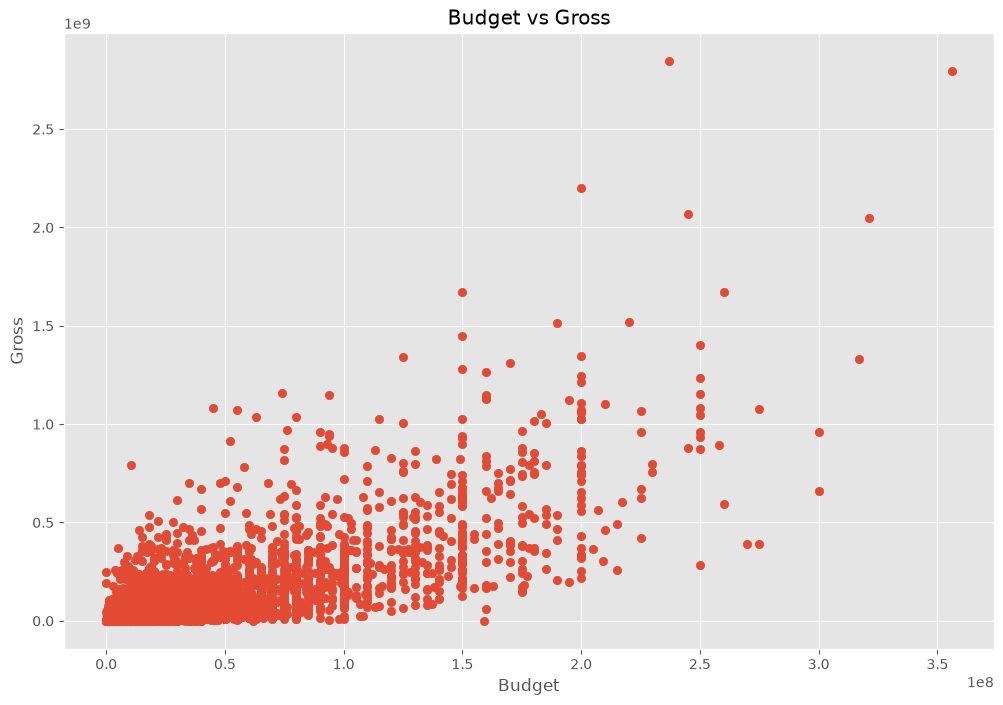

In [17]:
plt.scatter(x=df_clean['budget'],y=df_clean['gross'])
plt.title('Budget vs Gross')
plt.xlabel('Budget')
plt.ylabel('Gross')
plt.show

<Axes: xlabel='budget', ylabel='gross'>

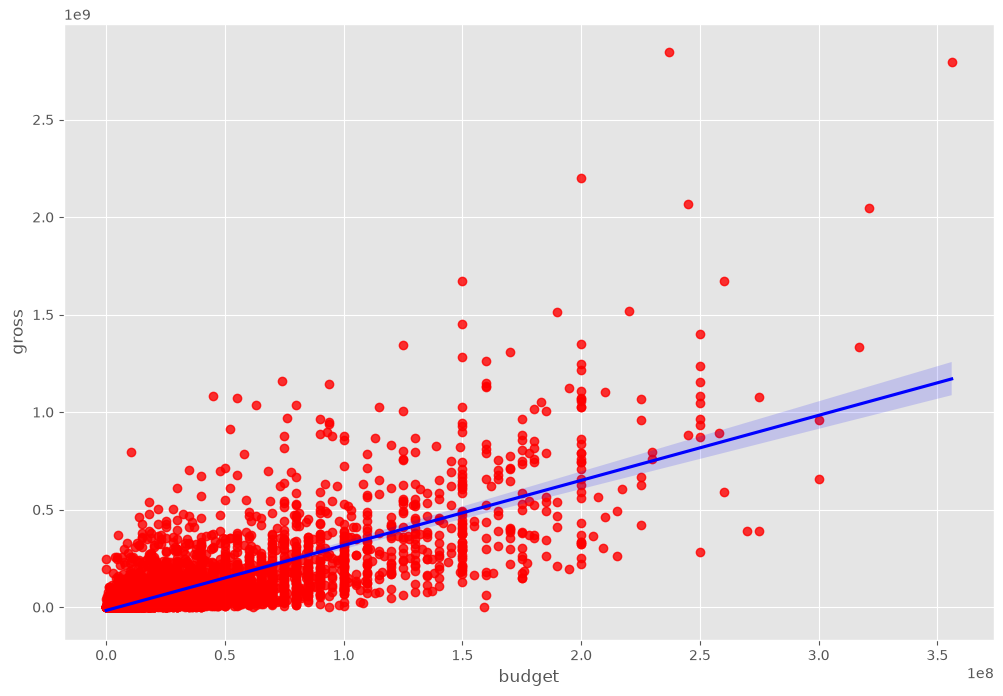

In [18]:
sns.regplot(x='budget',y='gross',data=df_clean,scatter_kws={"color":"red"},line_kws={"color":"blue"})

In [19]:
#查看关联性
#pearson,kendall,spearman
df_clean.corr(method='pearson',numeric_only=True)

,year,score,votes,budget,gross,runtime,released_year
year,1.000000,0.055391,0.205852,0.327793,0.274354,0.074203,0.998640
score,0.055391,1.000000,0.473789,0.071821,0.222100,0.414580,0.061243
votes,0.205852,0.473789,1.000000,0.440035,0.614895,0.352437,0.202975
budget,0.327793,0.071821,0.440035,1.000000,0.740410,0.318595,0.320255
gross,0.274354,0.222100,0.614895,0.740410,1.000000,0.275596,0.268713
runtime,0.074203,0.414580,0.352437,0.318595,0.275596,1.000000,0.074432
released_year,0.998640,0.061243,0.202975,0.320255,0.268713,0.074432,1.000000


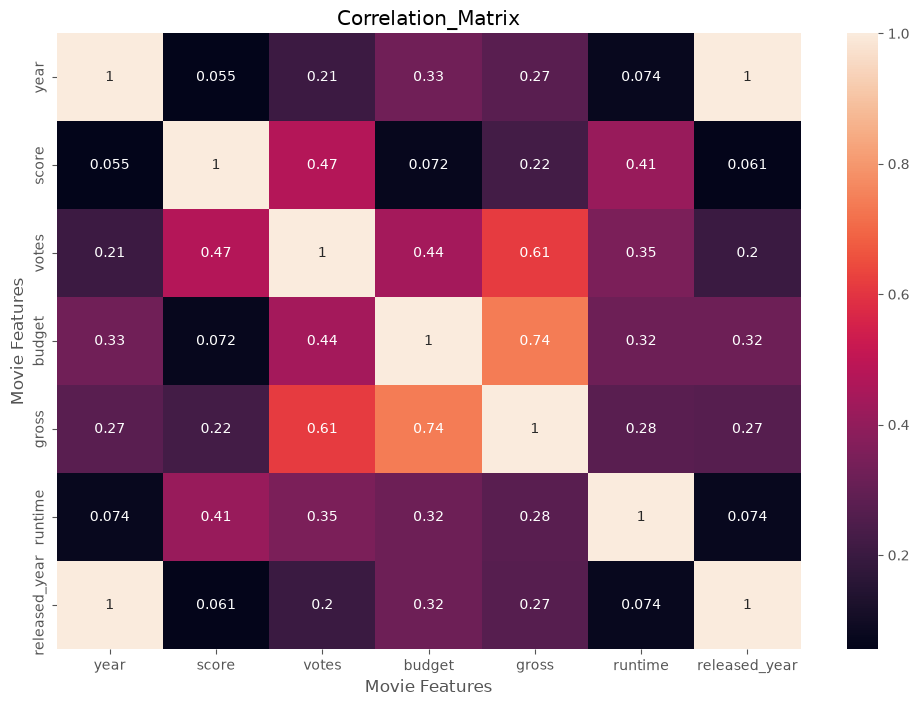

In [20]:
correlation_matrix=df_clean.corr(method='pearson',numeric_only=True)
sns.heatmap(correlation_matrix,annot=True)
plt.title('Correlation_Matrix')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [21]:
df_numerized=df_clean.copy()

In [22]:
from pandas.api.types import is_numeric_dtype

for col_name in df_numerized.columns:
    if not is_numeric_dtype(df_numerized[col_name]):
        df_numerized[col_name] = df_numerized[col_name].astype('category').cat.codes

df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
3743,387,5,0,2009,528,7.8,1100000.0,787,1265,1538,47,237000000,2847246203,1388,162.0,2009
5315,389,5,0,2019,138,8.4,903000.0,106,515,1474,47,356000000,2797501328,987,181.0,2019
1802,4922,5,6,1997,535,7.8,1100000.0,787,1265,1076,47,200000000,2201647264,1388,194.0,1997
4742,3655,5,0,2015,530,7.8,876000.0,770,1810,357,47,245000000,2069521700,949,138.0,2015
5171,390,5,0,2018,146,8.4,897000.0,106,515,1474,47,321000000,2048359754,987,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1385,2980,5,0,1993,1471,4.5,1900.0,1810,3111,187,47,5000000,2970,1382,97.0,1994
2295,1599,3,6,2000,1726,6.8,43000.0,954,1687,528,6,5000000,2554,468,108.0,2001
154,2920,6,9,1982,1530,3.9,2300.0,263,55,1477,47,800000,2270,584,85.0,1982
1379,2401,8,6,1993,64,7.3,5100.0,23,1220,1687,26,11900000,596,492,134.0,1993


In [23]:
df_clean

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
3743,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
5315,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
1802,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
4742,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
5171,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1385,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97.0,1994
2295,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108.0,2001
154,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85.0,1982
1379,Madadayo,Unknown,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0,1993


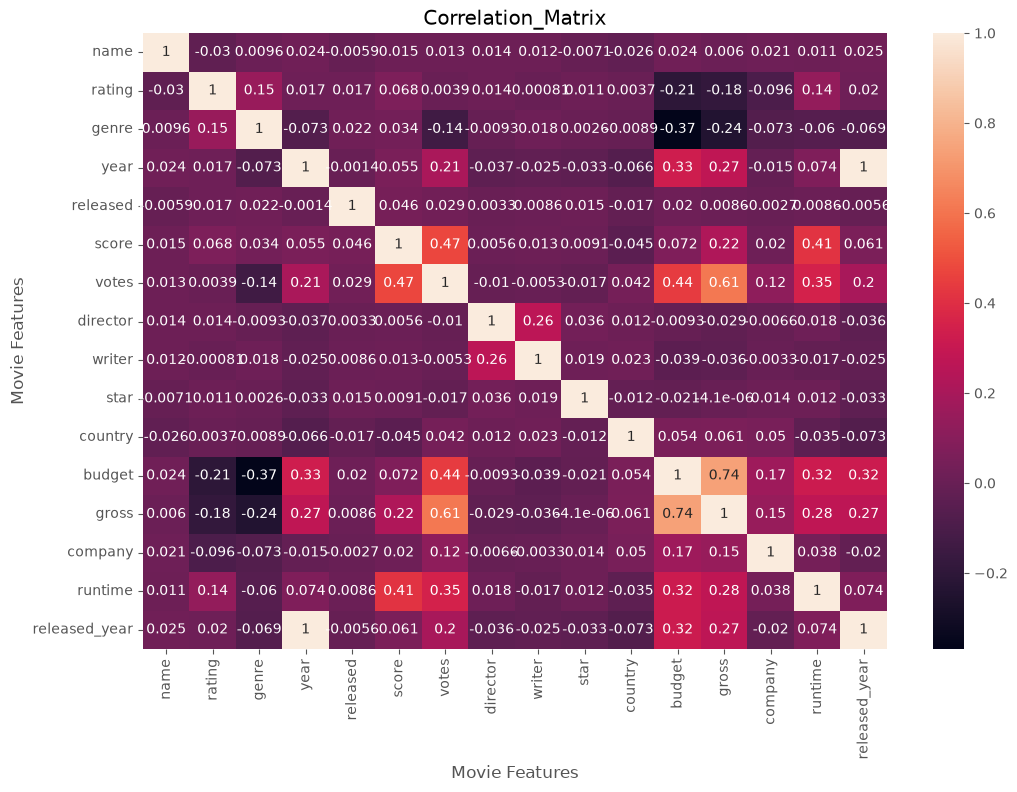

In [24]:
correlation_matrix=df_numerized.corr(method='pearson',numeric_only=True)
sns.heatmap(correlation_matrix,annot=True)
plt.title('Correlation_Matrix')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [25]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
name,1.000000,-0.029983,0.009647,0.024418,-0.005889,0.014981,0.012923,0.013698,0.011576,-0.007111,-0.025570,0.023695,0.005973,0.021353,0.010801,0.024717
rating,-0.029983,1.000000,0.152458,0.016515,0.017109,0.068266,0.003926,0.014082,-0.000812,0.011270,0.003671,-0.205917,-0.182420,-0.095559,0.137227,0.019789
genre,0.009647,0.152458,1.000000,-0.072815,0.021617,0.033805,-0.136573,-0.009300,0.017790,0.002638,-0.008895,-0.368932,-0.244499,-0.072848,-0.060186,-0.068639
year,0.024418,0.016515,-0.072815,1.000000,-0.001405,0.055391,0.205852,-0.036942,-0.024794,-0.032788,-0.065536,0.327793,0.274354,-0.014773,0.074203,0.998640
released,-0.005889,0.017109,0.021617,-0.001405,1.000000,0.046343,0.028998,0.003342,0.008619,0.015370,-0.017189,0.019896,0.008587,-0.002690,0.008619,-0.005550
score,0.014981,0.068266,0.033805,0.055391,0.046343,1.000000,0.473789,0.005577,0.013130,0.009139,-0.045143,0.071821,0.222100,0.020168,0.414580,0.061243
votes,0.012923,0.003926,-0.136573,0.205852,0.028998,0.473789,1.000000,-0.010196,-0.005301,-0.017134,0.041681,0.440035,0.614895,0.118732,0.352437,0.202975
director,0.013698,0.014082,-0.009300,-0.036942,0.003342,0.005577,-0.010196,1.000000,0.262973,0.036289,0.011960,-0.009341,-0.029365,-0.006616,0.018082,-0.036287
writer,0.011576,-0.000812,0.017790,-0.024794,0.008619,0.013130,-0.005301,0.262973,1.000000,0.019255,0.022789,-0.039448,-0.035920,-0.003283,-0.016671,-0.024619
star,-0.007111,0.011270,0.002638,-0.032788,0.015370,0.009139,-0.017134,0.036289,0.019255,1.000000,-0.011682,-0.021283,-0.000004,0.013716,0.012439,-0.033186


In [26]:
correlation_mat=df_numerized.corr()
corr_pairs=correlation_mat.unstack()
corr_pairs

name           name             1.000000
               rating          -0.029983
               genre            0.009647
               year             0.024418
               released        -0.005889
                                  ...   
released_year  budget           0.320255
               gross            0.268713
               company         -0.019555
               runtime          0.074432
               released_year    1.000000
Length: 256, dtype: float64

In [27]:
sort_pairs=corr_pairs.sort_values()
sort_pairs

genre          budget          -0.368932
budget         genre           -0.368932
gross          genre           -0.244499
genre          gross           -0.244499
rating         budget          -0.205917
                                  ...   
star           star             1.000000
company        company          1.000000
gross          gross            1.000000
runtime        runtime          1.000000
released_year  released_year    1.000000
Length: 256, dtype: float64

In [28]:
high_corr=sort_pairs[(sort_pairs)>0.5]
high_corr

gross          votes            0.614895
votes          gross            0.614895
gross          budget           0.740410
budget         gross            0.740410
year           released_year    0.998640
released_year  year             0.998640
director       director         1.000000
votes          votes            1.000000
released       released         1.000000
score          score            1.000000
rating         rating           1.000000
name           name             1.000000
genre          genre            1.000000
year           year             1.000000
budget         budget           1.000000
country        country          1.000000
writer         writer           1.000000
star           star             1.000000
company        company          1.000000
gross          gross            1.000000
runtime        runtime          1.000000
released_year  released_year    1.000000
dtype: float64